In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("50_Startups.csv")

In [3]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [6]:
X = df.iloc[:,0].values

In [7]:
Y = df.iloc[:,-1].values

In [8]:
X

array([165349.2 , 162597.7 , 153441.51, 144372.41, 142107.34, 131876.9 ,
       134615.46, 130298.13, 120542.52, 123334.88, 101913.08, 100671.96,
        93863.75,  91992.39, 119943.24, 114523.61,  78013.11,  94657.16,
        91749.16,  86419.7 ,  76253.86,  78389.47,  73994.56,  67532.53,
        77044.01,  64664.71,  75328.87,  72107.6 ,  66051.52,  65605.48,
        61994.48,  61136.38,  63408.86,  55493.95,  46426.07,  46014.02,
        28663.76,  44069.95,  20229.59,  38558.51,  28754.33,  27892.92,
        23640.93,  15505.73,  22177.74,   1000.23,   1315.46,      0.  ,
          542.05,      0.  ])

In [9]:
Y

array([192261.83, 191792.06, 191050.39, 182901.99, 166187.94, 156991.12,
       156122.51, 155752.6 , 152211.77, 149759.96, 146121.95, 144259.4 ,
       141585.52, 134307.35, 132602.65, 129917.04, 126992.93, 125370.37,
       124266.9 , 122776.86, 118474.03, 111313.02, 110352.25, 108733.99,
       108552.04, 107404.34, 105733.54, 105008.31, 103282.38, 101004.64,
        99937.59,  97483.56,  97427.84,  96778.92,  96712.8 ,  96479.51,
        90708.19,  89949.14,  81229.06,  81005.76,  78239.91,  77798.83,
        71498.49,  69758.98,  65200.33,  64926.08,  49490.75,  42559.73,
        35673.41,  14681.4 ])

# Train Test Split

In [30]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [31]:
len(X_train)

40

In [32]:
len(Y_train)

40

In [33]:
len(X_test)

10

In [34]:
len(Y_test)

10

In [35]:
x_train = X_train.reshape(-1,1)
x_test = X_test.reshape(-1,1)

# Feature Scaling

In [36]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [37]:
x_train

array([[ 0.34202149],
       [ 1.36207849],
       [-0.71081297],
       [ 0.90611438],
       [ 1.40997088],
       [ 1.20367103],
       [-1.05285826],
       [-1.61480906],
       [-1.642623  ],
       [ 0.77885123],
       [ 0.96515572],
       [ 0.00687736],
       [-0.01361318],
       [-0.66099544],
       [-0.34996231],
       [ 1.85350175],
       [-1.17369938],
       [-0.11798808],
       [-0.46926521],
       [ 1.14576723],
       [-0.25546817],
       [ 0.48597351],
       [-1.03655971],
       [ 1.79532434],
       [ 0.01483507],
       [ 1.6017269 ],
       [-1.3147716 ],
       [-0.66970778],
       [-0.21472284],
       [-1.03464471],
       [ 0.51221561],
       [-0.07809041],
       [ 0.29731084],
       [-1.642623  ],
       [-0.03032003],
       [ 1.11238589],
       [-1.14276186],
       [ 0.89344327],
       [-0.24603715],
       [-1.21489084]])

In [38]:
x_test

array([[ 0.30245367],
       [-0.82734624],
       [-0.33181874],
       [-1.62147425],
       [ 0.35879726],
       [-1.63116196],
       [-0.04987791],
       [-0.2753597 ],
       [-0.30191325],
       [ 0.18462534]])

# Create Linear Regression Model

In [39]:
regressor = LinearRegression()
regressor.fit(x_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# Predictions

In [40]:
y_pred = regressor.predict(x_test)

In [41]:
y_pred

array([127862.20996405,  82250.56334619, 102255.72078164,  50190.4734756 ,
       130136.88190548,  49799.36685472, 113638.0775288 , 104535.0534288 ,
       103463.04843113, 123105.31102669])

In [42]:
compare = pd.DataFrame({"Actual": Y_test,
                        "Predicted":y_pred})

In [43]:
compare

,Actual,Predicted
0,134307.35,127862.209964
1,81005.76,82250.563346
2,99937.59,102255.720782
3,64926.08,50190.473476
4,125370.37,130136.881905
5,35673.41,49799.366855
6,105733.54,113638.077529
7,107404.34,104535.053429
8,97427.84,103463.048431
9,122776.86,123105.311027


# Plotting of y_test vs y_pred


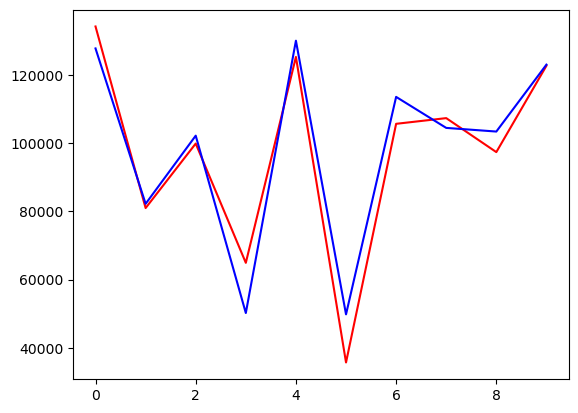

In [44]:
plt.plot(Y_test, color = "red", label = "Actual")
plt.plot(y_pred, color = "blue", label = "Prediction")
plt.show()

# Out of the box Predictions

In [51]:
data = [[80000]]
new_df = pd.DataFrame(data)

In [52]:
new_df = sc.transform(new_df)

In [53]:
new_df

array([[0.04888793]])

In [54]:
newData_Predict = regressor.predict(new_df)

In [55]:
newData_Predict

array([117625.39663918])